<a href="https://colab.research.google.com/github/Sebas-Atehortua/Integracion-de-Datos-y-Prospectiva/blob/main/Integraci%C3%B3n_Credibilidad_FINTECH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Integración de Datos y Credibilidad – Caso FINTECH**

El presente modelo tiene como objetivo integrar información interna y externa sobre eventos de fallos tecnológicos en una FINTECH, con el fin de obtener una estimación más robusta y estadísticamente consistente de la Distribución Agregada de Pérdidas (LDA).

Dado que la información interna puede ser limitada en tamaño muestral y la información externa puede diferir en estructura de riesgo, se emplea la Teoría de la Credibilidad para determinar el ***grado de afinidad o compatibilidad*** entre ambas bases de datos y establecer una ponderación óptima en el proceso de integración.

Para ello, el análisis se estructura en conocer las siguientes variables:

*   Frecuencia: Número de transacciones fallidas por día
*   Severidad: Impacto económico que se asocia a cada evento
*   Distribución Agregada de Pérdidas (LDA) como el producto entre ambas, sin embargo, se emplea el Método de Montecarlo para simular múltiples escenarios posibles de pérdida diaria y así caracterizar la distribución completa del riesgo.

Es así que, para el enriquecimiento de los datos se utilizarán como referencia el Método de Montecarlo (Ruleta Cargada - Muestreo Aleatorio) y la Teoría de la Credibilidad, la cual muestra cuál es la afinidad que poseen datos externos (AdmonEjecProcesos) frente a los datos que poseo internamente (Fallos_Tecnológicos).

0. Se cargan las librerías de trabajo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Configuración de estilo
sns.set_theme(style="whitegrid")

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Se montan los archivos de trabajo.

0      0.5374
1      4.7912
2      2.1345
3      6.4884
4      8.4735
        ...  
696    0.5747
697    4.3254
698    3.6280
699    1.0860
700    3.7288
Length: 701, dtype: float64
0      0.395144
1      0.148815
2      0.349362
3      0.107869
4      0.819804
         ...   
345    0.578173
346    0.108817
347    3.487451
348    0.048614
349    0.560543
Length: 350, dtype: float64


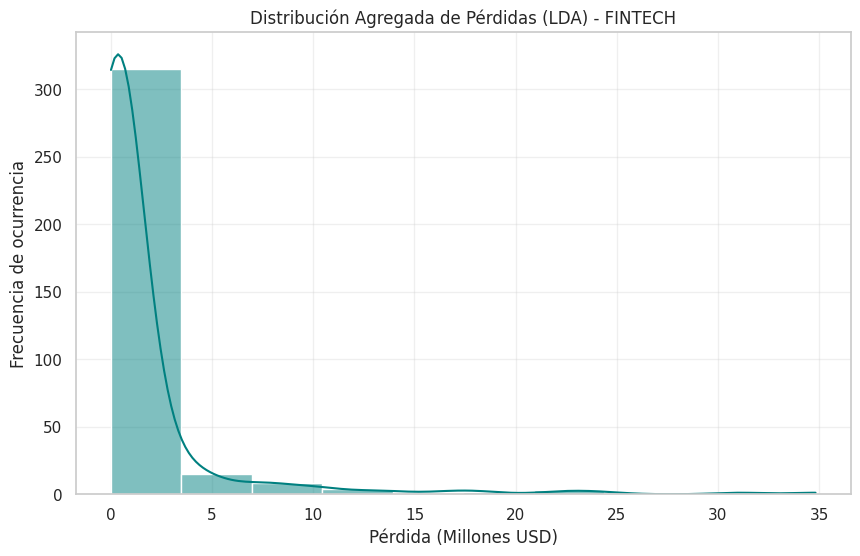

In [ ]:
# Cargar base interna (Fallos Tecnológicos)
bd_int = pd.read_excel('/content/drive/MyDrive/Proyecto FINTECH_2/1. FallasTecnológicas.xlsx')
bd_int.head(10)

# Determinamos la frecuencia y severidad de la base interna

Freq=bd_int.iloc[:,3]
Sev=bd_int.iloc[:,4]
LDA_interna=Freq*Sev
print(LDA_interna)

# Cargar base externa (AdmonEjecProcesos)
bd_ext = pd.read_excel('/content/drive/MyDrive/Proyecto FINTECH_2/2. AdmonEjecProcesos.xlsx')
bd_ext.head(10)

# Determinamos la frecuencia y severidad de la base interna

Freq_ext=bd_ext.iloc[:,3]
Sev_ext=bd_ext.iloc[:,4]
LDA_externa=Freq_ext*Sev_ext
print(LDA_externa)

# Visualizamos inicialmente los datos usando la librería Seaborn

plt.figure(figsize=(10, 6))
sns.histplot(LDA_externa, bins=10, kde=True, color='teal')
plt.title("Distribución Agregada de Pérdidas (LDA) - FINTECH")
plt.xlabel("Pérdida (Millones USD)")
plt.ylabel("Frecuencia de ocurrencia")
plt.grid(True, alpha=0.3)
plt.show()

2. Se crea el método de caracterización de las variables

In [ ]:
def caracterizacion(X, nombre):

    print(f"\n===== {nombre} =====")

    media = round(np.mean(X), 2)
    varianza = round(np.var(X), 2)
    desviacion = round(np.std(X), 2)
    asimetria = round(skew(X), 2)
    curtosis = round(kurtosis(X), 2)

    print("Media:", media)
    print("Varianza:", varianza)
    print("Desviación:", desviacion)
    print("Asimetría:", asimetria)
    print("Curtosis:", curtosis)

    plt.figure(figsize=(6,4))
    sns.histplot(X, bins=15, kde=True)
    plt.title(f"Distribución de la {nombre}")
    plt.xlabel("Pérdida (Millones USD)")
    plt.ylabel("Frecuencia de ocurrencia")
    plt.grid()
    plt.show()

    return media, varianza, desviacion, asimetria, curtosis

**2.1.** Caracterizamos las variables.
(Se determinan las medidas de frecuencia central, asimetría y curtosis para las bases de datos)


===== LDA Interna =====
Media: 9.45
Varianza: 187.89
Desviación: 13.71
Asimetría: 3.35
Curtosis: 14.17


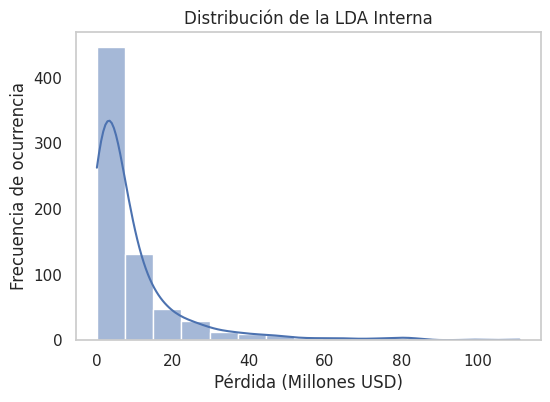


===== LDA Externa =====
Media: 1.47
Varianza: 16.07
Desviación: 4.01
Asimetría: 5.06
Curtosis: 29.64


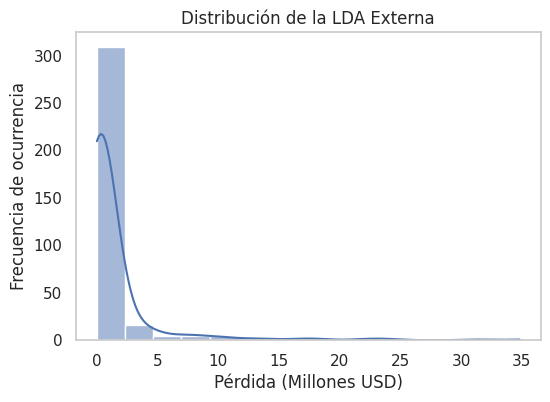

In [ ]:
uo, varo, sigmao, Caso, Kuo = caracterizacion(LDA_interna, "LDA Interna")
ue, vare, sigmae, Case, Kue = caracterizacion(LDA_externa, "LDA Externa")

3. Elaboramos la Teoría de la Credibilidad

In [67]:

# 0. Tamaños de las muestras
NDo = len(LDA_interna)      # Base interna
NDe = len(LDA_externa)     # Base externa

# 1. Media hipotética combinada
uhat = (NDo*uo + NDe*ue) / (NDo + NDe)

# 2. EPV (Expected Process Variance)
EPV = (NDo*sigmao**2 + NDe*sigmae**2) / (NDo + NDe)

# 3. VHM (Variance of Hypothetical Means)
VHM = ((NDo*uo**2 + NDe*ue**2) / (NDo + NDe)) - uhat**2

# 4. Parámetro K
K = EPV / VHM

# 5. Factor de credibilidad interna (Bühlmann)
Z = NDo / (NDo + K)

# 6. Credibilidad externa
Z_ext = 1 - Z

print("K:", round(K,4))
print("Credibilidad Interna (Z):", round(Z,4))
print("Credibilidad Externa:", round(Z_ext,4))

K: 9.2421
Credibilidad Interna (Z): 0.987
Credibilidad Externa: 0.013


3.1. Conclusión de la teoría de credibilidad

La aplicación del modelo de credibilidad de Bühlmann arroja un factor de credibilidad interna de 98.7%, indicando que la experiencia histórica propia de la FINTECH es estadísticamente robusta y suficiente para estimar el nivel esperado de pérdidas operacionales.

En consecuencia, la información externa tiene una influencia marginal (1.3%), por lo que el capital económico estará determinado principalmente por la dinámica interna de pérdidas.

3.2. Se grafican las LDA para observar las diferencias de distribución

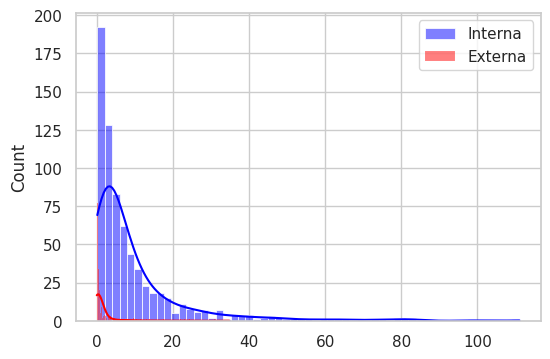

In [69]:
plt.figure(figsize=(6,4))
sns.histplot(LDA_interna, color='blue', label='Interna', kde=True)
sns.histplot(LDA_externa, color='red', label='Externa', kde=True)
plt.legend()
plt.show()

**Análisis**: El análisis gráfico evidencia una fuerte concentración de la base externa en niveles bajos de pérdida, mientras que la base interna presenta mayor dispersión y eventos extremos significativos. La superposición parcial en la región de bajas pérdidas y el tamaño muestral interno justifican el alto factor de credibilidad (Z=0.987), validando la predominancia de la experiencia interna en la estimación del riesgo agregado.